In [7]:
# Cell 1 — Configuration
import numpy as np
import h5py
from pathlib import Path

# ── Paths (mirror visualisation.ipynb convention) ──────────────────────────
NOTEBOOK_DIR  = Path().resolve()
file_prefix   = ""          # set to match inputfile_generator prefix, e.g. "fracture_10cm"
output_subdir = "Experiment_3"          # set to match run_experiment --subdir, e.g. "run_01"

def _stem(suffix):
    return f"{file_prefix}_{suffix}" if file_prefix else suffix

out_dir       = NOTEBOOK_DIR  / output_subdir if output_subdir else NOTEBOOK_DIR
BASELINE_OUT  = out_dir / f"{_stem('baseline')}.out"
TIMELAPSE_OUT = out_dir / f"{_stem('timelapse')}.out"

# ── Geometry ───────────────────────────────────────────────────────────────
c_ice          = 1.69e8      # [m/s] wave velocity in ice
fracture_depth = 0.6         # [m]   depth of fracture interface
tx_x           = 0.0         # [m]   transmitter x-position
n_rx           = 100
rx_spacing     = 0.02        # [m]
rx_start       = 0.02        # [m]
rx_positions   = np.array([rx_start + i * rx_spacing for i in range(n_rx)])

# ── Analysis parameters ────────────────────────────────────────────────────
f_central         = 1.5e9    # [Hz] GPR centre frequency
PHASE_MASK_THRESH = 0.08     # mask where envelope < 8 % of peak
GAUSS_SIGMA       = 1.5      # Gaussian smoothing sigma for phase residual map
XWT_FREQ_MIN      = 0.5e9    # [Hz] lower bound for XWT / coherence display
XWT_FREQ_MAX      = 4.0e9    # [Hz] upper bound
XWT_TRACE_IDX     = None     # None -> auto-select centre receiver for XWT

print(f"Baseline:  {BASELINE_OUT}")
print(f"Timelapse: {TIMELAPSE_OUT}")
print(f"rx_positions: {rx_positions[0]:.3f} .. {rx_positions[-1]:.3f} m  (n={len(rx_positions)})")

Baseline:  C:\Users\Administrator\OneDrive\Thesis\TimeLapse_Notebooks\Experiment_3\baseline.out
Timelapse: C:\Users\Administrator\OneDrive\Thesis\TimeLapse_Notebooks\Experiment_3\timelapse.out
rx_positions: 0.020 .. 2.000 m  (n=100)


In [8]:
# Cell 2 — Data loading + normalization

def load_out(path):
    """Load gprMax .out file. Returns (traces, time_ns, dt_ns).
    Collects all /rxs/rxN/Ez groups -> traces shape (n_rx, n_time).
    """
    with h5py.File(path, "r") as f:
        dt_ns   = f.attrs["dt"] * 1e9
        n_iter  = f.attrs["Iterations"]
        time_ns = np.arange(n_iter) * dt_ns
        rxs     = sorted(f["/rxs"].keys(), key=lambda k: int(k[2:]))
        traces  = np.stack([f[f"/rxs/{rx}/Ez"][:] for rx in rxs], axis=0)
    return traces, time_ns, dt_ns

print("Loading baseline ...")
raw_b,  time_ns, dt_ns = load_out(BASELINE_OUT)
print("Loading timelapse ...")
raw_tl, _,       _     = load_out(TIMELAPSE_OUT)

# Normalize each B-scan to its own peak — prevents energy bias in Hilbert
baseline_norm  = raw_b  / np.max(np.abs(raw_b))
timelapse_norm = raw_tl / np.max(np.abs(raw_tl))

amp_ratio = np.max(np.abs(raw_tl)) / np.max(np.abs(raw_b))
dt_s      = dt_ns * 1e-9
print(f"dt = {dt_ns:.4f} ns | n_time = {len(time_ns)} | n_rx = {raw_b.shape[0]}")
print(f"Amplitude ratio (TL/BL) = {amp_ratio:.4f}")

Loading baseline ...
Loading timelapse ...
dt = 0.0018 ns | n_time = 8000 | n_rx = 100
Amplitude ratio (TL/BL) = 1.0000


In [9]:
# Cell 3 — Analysis and visualization functions
import matplotlib.pyplot as plt
import pywt
from scipy.signal  import hilbert
from scipy.ndimage import gaussian_filter

# ── 3a. Instantaneous phase ────────────────────────────────────────────────

def extract_phase(traces):
    """Return (envelope, unwrapped_phase) for traces (n_rx, n_time)."""
    analytic = hilbert(traces, axis=1)
    envelope = np.abs(analytic)
    phase    = np.unwrap(np.angle(analytic), axis=1)
    return envelope, phase


def compute_phase_residual(phase_b, phase_tl, env_b, env_tl, threshold, sigma):
    """
    Phase residual map Delta_phi = phase_tl - phase_b.
    Masked where either envelope is below threshold * global_peak.
    Gaussian-smoothed with sigma pixels.
    Returns (residual_masked, mask_bool).
    """
    global_peak     = max(env_b.max(), env_tl.max())
    mask            = (env_b > threshold * global_peak) & (env_tl > threshold * global_peak)
    residual        = phase_tl - phase_b
    residual        = gaussian_filter(residual, sigma=sigma)
    residual_masked = np.where(mask, residual, np.nan)
    return residual_masked, mask


# ── 3b. Cross-Wavelet Transform ───────────────────────────────────────────

def compute_xwt(trace1, trace2, dt_s, freq_min_hz, freq_max_hz, n_freqs=64,
                wavelet="cmor1.5-1.0"):
    """
    Compute XWT, power, and wavelet coherence for two 1-D traces.
    Returns (freqs_hz, xwt, power, coherence, xwt_phase).
    """
    freqs_hz = np.geomspace(freq_min_hz, freq_max_hz, n_freqs)
    scales   = pywt.frequency2scale(wavelet, freqs_hz * dt_s)

    cwt1, _ = pywt.cwt(trace1, scales, wavelet, sampling_period=dt_s)
    cwt2, _ = pywt.cwt(trace2, scales, wavelet, sampling_period=dt_s)

    xwt       = cwt1 * np.conj(cwt2)
    power     = np.abs(xwt)
    xwt_phase = np.angle(xwt)

    # Wavelet coherence: smooth(|XWT|^2) / (smooth(|CWT1|^2) * smooth(|CWT2|^2))
    sm_xwt  = gaussian_filter(np.abs(xwt)**2,  sigma=2)
    sm_cwt1 = gaussian_filter(np.abs(cwt1)**2, sigma=2)
    sm_cwt2 = gaussian_filter(np.abs(cwt2)**2, sigma=2)
    denom     = sm_cwt1 * sm_cwt2
    coherence = np.where(denom > 0, sm_xwt / denom, 0.0)

    return freqs_hz, xwt, power, coherence, xwt_phase


# ── 3c. Plot: Phase Difference Map ────────────────────────────────────────

def plot_phase_diff_map(residual_masked, time_ns, rx_pos, fracture_depth, c_ice, title):
    """2-D phase residual map. Cyclic twilight colormap, range +-pi."""
    fig, ax = plt.subplots(figsize=(12, 6))
    t_frac  = fracture_depth / c_ice * 2 * 1e9   # two-way time [ns]
    im = ax.imshow(
        residual_masked.T,
        aspect="auto",
        cmap="twilight",
        origin="upper",
        extent=[rx_pos[0], rx_pos[-1], time_ns[-1], time_ns[0]],
        vmin=-np.pi,
        vmax= np.pi,
    )
    ax.axhline(t_frac, color="cyan", linestyle="--", linewidth=1.2,
               label=f"Fracture TWTT ({t_frac:.1f} ns)")
    ax.legend(loc="upper right", fontsize=9)
    ax.set_title(title, fontsize=14, weight="bold")
    ax.set_xlabel("Receiver x (m)", fontsize=12)
    ax.set_ylabel("Two-way travel time (ns)", fontsize=12)
    cbar = fig.colorbar(im, ax=ax, pad=0.02)
    cbar.set_label("Phase residual (rad)", fontsize=10)
    plt.tight_layout()
    return fig


# ── 3d. Plot: Phase vs. Offset profile ───────────────────────────────────

def plot_phase_vs_offset(residual_masked, time_ns, rx_pos, fracture_depth, c_ice, title):
    """1-D phase residual profile extracted at the fracture TWTT."""
    dt_ns  = time_ns[1] - time_ns[0]
    t_frac = fracture_depth / c_ice * 2 * 1e9
    t_idx  = int(np.round((t_frac - time_ns[0]) / dt_ns))
    t_idx  = max(0, min(t_idx, len(time_ns) - 1))

    profile = residual_masked[:, t_idx]

    fig, ax = plt.subplots(figsize=(10, 4))
    ax.plot(rx_pos, profile, color="steelblue", linewidth=1.5)
    ax.axhline(0, color="grey", linewidth=0.8, linestyle="--")
    ax.set_title(title, fontsize=14, weight="bold")
    ax.set_xlabel("Receiver x (m)", fontsize=12)
    ax.set_ylabel("Phase residual (rad)", fontsize=12)
    ax.set_ylim(-np.pi, np.pi)
    ax.text(0.02, 0.95, f"t = {t_frac:.1f} ns (fracture TWTT)",
            transform=ax.transAxes, fontsize=9, va="top")
    plt.tight_layout()
    return fig


# ── 3e. Plot: Wavelet Coherence + phase arrows ────────────────────────────

def plot_xwt_coherence(coherence, freqs_hz, time_ns, xwt_phase,
                       f_central, title, arrow_stride=8):
    """
    Wavelet coherence imshow (0-1) with phase arrows overlaid.
    Arrow stride controls quiver density.
    """
    fig, ax = plt.subplots(figsize=(12, 6))
    im = ax.imshow(
        coherence,
        aspect="auto",
        cmap="viridis",
        origin="upper",
        extent=[time_ns[0], time_ns[-1], freqs_hz[-1] / 1e9, freqs_hz[0] / 1e9],
        vmin=0, vmax=1,
    )
    # Phase arrows subsampled for readability
    t_sub  = np.arange(0, coherence.shape[1], arrow_stride)
    f_sub  = np.arange(0, coherence.shape[0], arrow_stride)
    ph_sub = xwt_phase[np.ix_(f_sub, t_sub)]
    U      = np.cos(ph_sub)
    V      = np.sin(ph_sub)
    t_vals = time_ns[t_sub]
    f_vals = freqs_hz[f_sub] / 1e9
    T_plot, F_plot = np.meshgrid(t_vals, f_vals)
    ax.quiver(T_plot, F_plot, U, V, scale=30, headwidth=3,
              headlength=4, color="white", alpha=0.7, width=0.003)

    ax.axhline(f_central / 1e9, color="cyan", linestyle="--", linewidth=1.0,
               label=f"f_c = {f_central/1e9:.1f} GHz")
    ax.legend(loc="upper right", fontsize=9)
    ax.set_title(title, fontsize=14, weight="bold")
    ax.set_xlabel("Two-way travel time (ns)", fontsize=12)
    ax.set_ylabel("Frequency (GHz)", fontsize=12)
    cbar = fig.colorbar(im, ax=ax, pad=0.02)
    cbar.set_label("Wavelet coherence", fontsize=10)
    plt.tight_layout()
    return fig


print("Functions defined.")

Functions defined.


CWT on trace 50  (x = 1.020 m) ...


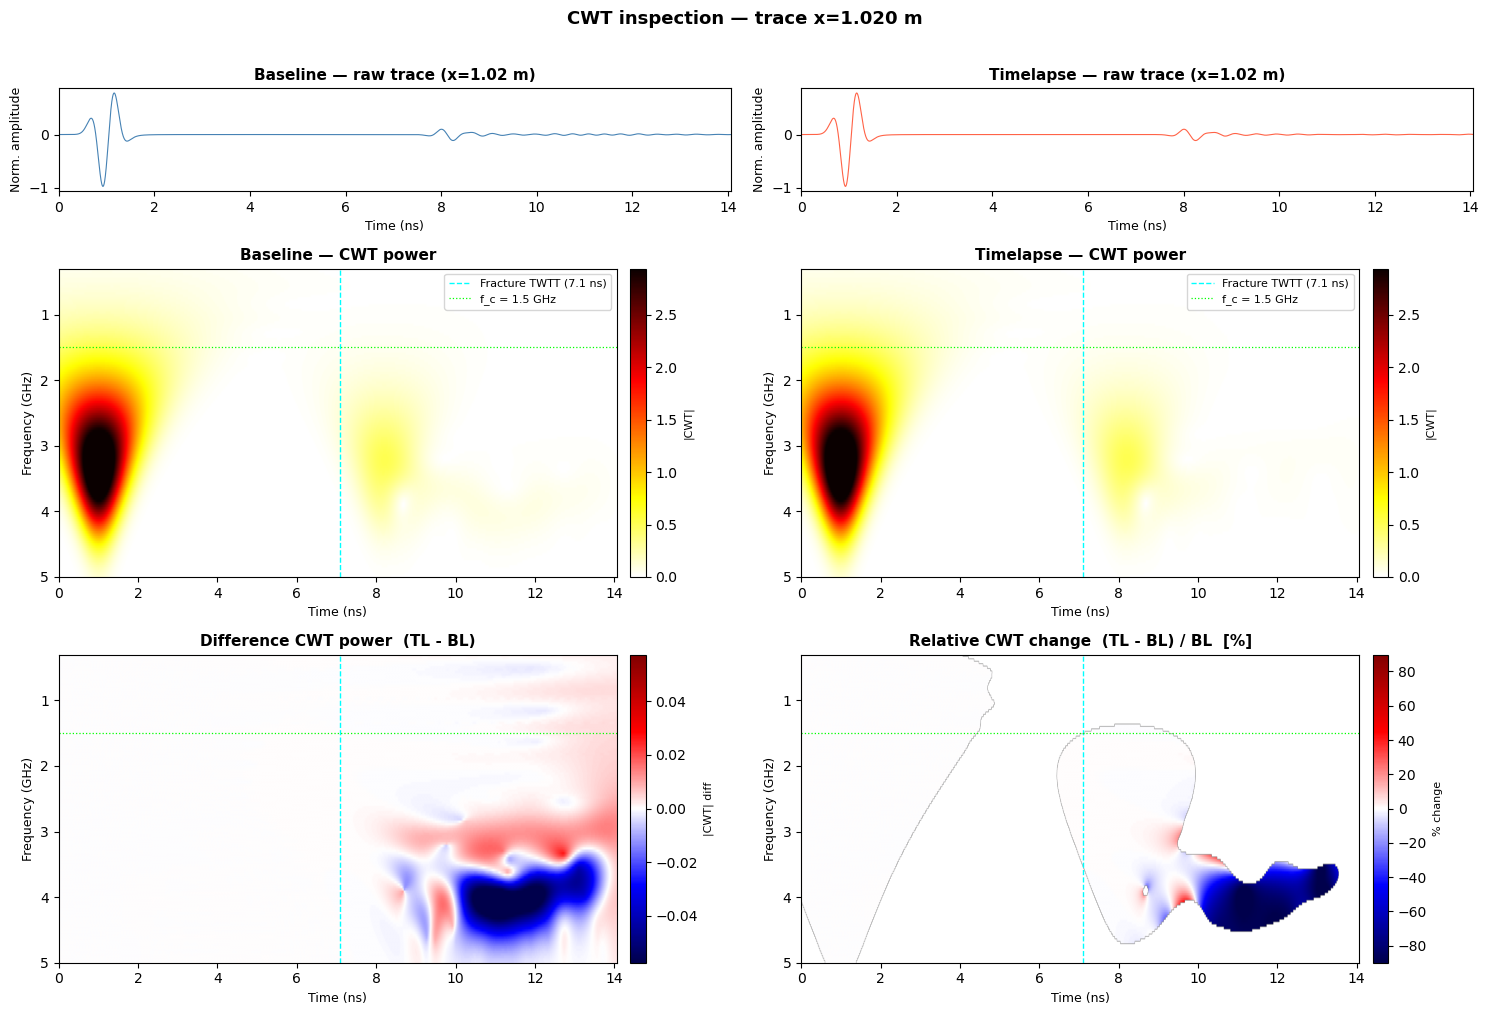

Done.


In [10]:
# Cell 4 — CWT scalogram: single trace inspection

import matplotlib.pyplot as plt
import pywt
import numpy as np

TRACE_IDX = len(rx_positions) // 2   # centre receiver; change to inspect others

wavelet  = "cmor1.5-1.0"
n_freqs  = 128
freqs_hz = np.geomspace(0.3e9, 5.0e9, n_freqs)
scales   = pywt.frequency2scale(wavelet, freqs_hz * dt_s)

trace_b  = baseline_norm[TRACE_IDX]
trace_tl = timelapse_norm[TRACE_IDX]

print(f"CWT on trace {TRACE_IDX}  (x = {rx_positions[TRACE_IDX]:.3f} m) ...")
cwt_b,  _ = pywt.cwt(trace_b,  scales, wavelet, sampling_period=dt_s)
cwt_tl, _ = pywt.cwt(trace_tl, scales, wavelet, sampling_period=dt_s)

power_b  = np.abs(cwt_b)
power_tl = np.abs(cwt_tl)
vmax     = max(np.percentile(power_b, 99), np.percentile(power_tl, 99))

fig, axes = plt.subplots(3, 2, figsize=(15, 10),
                         gridspec_kw={"height_ratios": [1, 3, 3]})

# ── Row 0: raw traces ──────────────────────────────────────────────────────
for ax, trace, label, color in zip(
        axes[0], [trace_b, trace_tl],
        ["Baseline", "Timelapse"], ["steelblue", "tomato"]):
    ax.plot(time_ns, trace, color=color, linewidth=0.8)
    ax.set_title(f"{label} — raw trace (x={rx_positions[TRACE_IDX]:.2f} m)",
                 fontsize=11, weight="bold")
    ax.set_xlabel("Time (ns)", fontsize=9)
    ax.set_ylabel("Norm. amplitude", fontsize=9)
    ax.set_xlim(time_ns[0], time_ns[-1])

# ── Rows 1-2: scalograms ───────────────────────────────────────────────────
extent = [time_ns[0], time_ns[-1], freqs_hz[-1] / 1e9, freqs_hz[0] / 1e9]

for ax, power, label in zip(
        axes[1], [power_b, power_tl], ["Baseline", "Timelapse"]):
    im = ax.imshow(power, aspect="auto", cmap="hot_r", origin="upper",
                   extent=extent, vmin=0, vmax=vmax)
    t_frac = fracture_depth / c_ice * 2 * 1e9
    ax.axvline(t_frac, color="cyan", linestyle="--", linewidth=1.0,
               label=f"Fracture TWTT ({t_frac:.1f} ns)")
    ax.axhline(f_central / 1e9, color="lime", linestyle=":", linewidth=0.9,
               label=f"f_c = {f_central/1e9:.1f} GHz")
    ax.legend(fontsize=8, loc="upper right")
    ax.set_title(f"{label} — CWT power", fontsize=11, weight="bold")
    ax.set_xlabel("Time (ns)", fontsize=9)
    ax.set_ylabel("Frequency (GHz)", fontsize=9)
    fig.colorbar(im, ax=ax, pad=0.02).set_label("|CWT|", fontsize=8)

# ── Row 2: difference scalogram ───────────────────────────────────────────
diff_power = power_tl - power_b
vlim = np.percentile(np.abs(diff_power), 99)

ax_d0, ax_d1 = axes[2]
im2 = ax_d0.imshow(diff_power, aspect="auto", cmap="seismic", origin="upper",
                   extent=extent, vmin=-vlim, vmax=vlim)
ax_d0.axvline(t_frac, color="cyan", linestyle="--", linewidth=1.0)
ax_d0.axhline(f_central / 1e9, color="lime", linestyle=":", linewidth=0.9)
ax_d0.set_title("Difference CWT power  (TL - BL)", fontsize=11, weight="bold")
ax_d0.set_xlabel("Time (ns)", fontsize=9)
ax_d0.set_ylabel("Frequency (GHz)", fontsize=9)
fig.colorbar(im2, ax=ax_d0, pad=0.02).set_label("|CWT| diff", fontsize=8)

# relative change (%) where baseline power > 1 % of max
rel = np.where(power_b > 0.01 * power_b.max(),
               100 * diff_power / power_b, np.nan)
vlim_r = np.nanpercentile(np.abs(rel), 99)
im3 = ax_d1.imshow(rel, aspect="auto", cmap="seismic", origin="upper",
                   extent=extent, vmin=-vlim_r, vmax=vlim_r)
ax_d1.axvline(t_frac, color="cyan", linestyle="--", linewidth=1.0)
ax_d1.axhline(f_central / 1e9, color="lime", linestyle=":", linewidth=0.9)
ax_d1.set_title("Relative CWT change  (TL - BL) / BL  [%]", fontsize=11, weight="bold")
ax_d1.set_xlabel("Time (ns)", fontsize=9)
ax_d1.set_ylabel("Frequency (GHz)", fontsize=9)
fig.colorbar(im3, ax=ax_d1, pad=0.02).set_label("% change", fontsize=8)

plt.suptitle(f"CWT inspection — trace x={rx_positions[TRACE_IDX]:.3f} m",
             fontsize=13, weight="bold", y=1.01)
plt.tight_layout()
plt.show()
print("Done.")

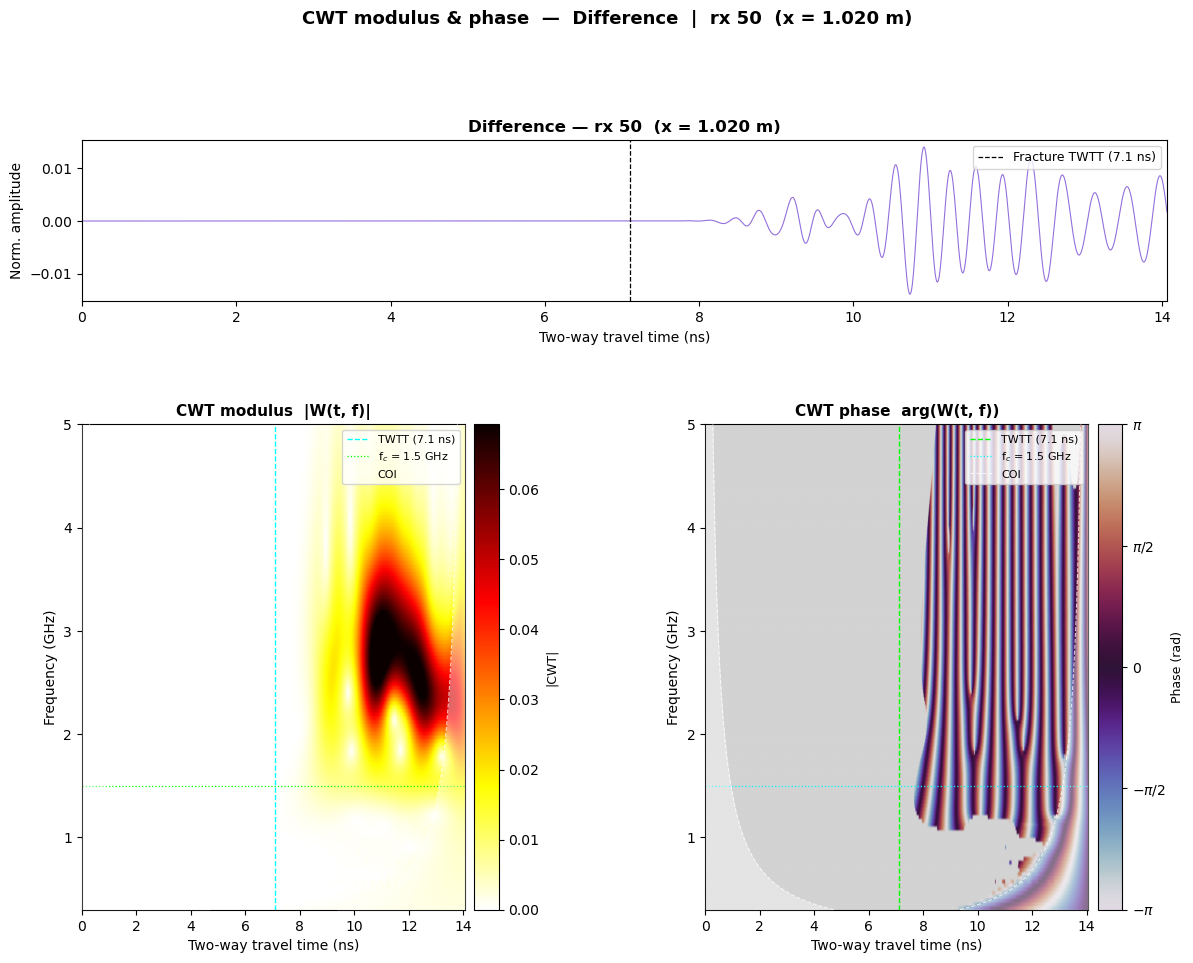

In [27]:
# Cell 5 — CWT modulus & phase: selectable trace and dataset

def _add_coi(ax, freqs_hz, time_ns, alpha=0.40):
    """
    Overlay the cone of influence (COI) on a scalogram axes as a lighter shade.

    The COI half-width at frequency f is t_coi = sqrt(2) / f  [Torrence & Compo 1998],
    the e-folding time beyond which edge effects become significant.  Regions
    within the COI from either end of the signal are shaded with a semi-transparent
    white patch; the boundary is drawn as a dashed white line.
    """
    t_total_ns = time_ns[-1]
    freqs_ghz  = freqs_hz / 1e9
    t_coi_ns   = np.sqrt(2) / freqs_hz * 1e9   # COI half-width [ns] per frequency

    # Left-edge COI
    ax.fill_betweenx(freqs_ghz,
                     np.full_like(freqs_ghz, time_ns[0]),
                     np.minimum(time_ns[0] + t_coi_ns, t_total_ns),
                     color="white", alpha=alpha, linewidth=0, zorder=3)

    # Right-edge COI
    ax.fill_betweenx(freqs_ghz,
                     np.maximum(t_total_ns - t_coi_ns, time_ns[0]),
                     np.full_like(freqs_ghz, t_total_ns),
                     color="white", alpha=alpha, linewidth=0, zorder=3)

    # COI boundary lines (only where the cone fits within the signal)
    valid = t_coi_ns < 0.5 * (t_total_ns - time_ns[0])
    if valid.any():
        kw = dict(color="white", linestyle="--", linewidth=0.8, alpha=0.75, zorder=4)
        ax.plot(time_ns[0]  + t_coi_ns[valid], freqs_ghz[valid], **kw, label="COI")
        ax.plot(t_total_ns  - t_coi_ns[valid], freqs_ghz[valid], **kw)


def plot_cwt_modulus_phase(
    trace_idx,
    dataset="baseline",
    n_freqs=128,
    freq_min_hz=0.3e9,
    freq_max_hz=5.0e9,
    wavelet="cmor1.5-1.0",
    cmap_mod="hot_r",
    cmap_phase="twilight",
    show_phase_arrows=True,
    arrow_stride=16,
    show_coi=True,
    coi_alpha=0.40,
):
    """
    Plot CWT modulus and phase scalograms for a single GPR trace.

    Parameters
    ----------
    trace_idx : int
        Receiver index (0 to n_rx-1).
    dataset : {'baseline', 'timelapse', 'difference'}
        Which B-scan to draw the trace from.
    n_freqs : int
        Number of frequency bins.
    freq_min_hz, freq_max_hz : float
        Frequency range for the CWT [Hz].
    wavelet : str
        PyWavelets wavelet name — complex Morlet 'cmor1.5-1.0' recommended.
    cmap_mod, cmap_phase : str
        Colormaps for the modulus and phase panels.
    show_phase_arrows : bool
        Overlay phase-direction arrows on the phase panel (Grinsted et al. style).
    arrow_stride : int
        Pixel stride for quiver arrows; larger = sparser.
    show_coi : bool
        Shade the cone of influence where edge effects may distort the scalogram.
    coi_alpha : float
        Opacity of the COI white overlay (0 = invisible, 1 = fully opaque).

    Returns
    -------
    fig : matplotlib.figure.Figure
    """
    # ── Select trace ──────────────────────────────────────────────────────────
    datasets = {
        "baseline":   ("Baseline",   baseline_norm),
        "timelapse":  ("Timelapse",  timelapse_norm),
        "difference": ("Difference", timelapse_norm - baseline_norm),
    }
    if dataset not in datasets:
        raise ValueError(f"dataset must be one of {list(datasets)}, got {dataset!r}")

    ds_label, bscan = datasets[dataset]
    trace = bscan[trace_idx]
    rx_x  = rx_positions[trace_idx]

    # ── CWT ──────────────────────────────────────────────────────────────────
    # Linear spacing needed for imshow (otherwise features skew vertically)
    freqs_hz = np.linspace(freq_min_hz, freq_max_hz, n_freqs)
    scales   = pywt.frequency2scale(wavelet, freqs_hz * dt_s)
    cwt, _   = pywt.cwt(trace, scales, wavelet, sampling_period=dt_s)

    modulus = np.abs(cwt)
    phase   = np.angle(cwt)           # wrapped phase in (-pi, pi]

    # Mask numerical noise in phase where signal energy is very low
    phase_masked = np.copy(phase)
    phase_masked[modulus < 0.01 * modulus.max()] = np.nan

    # ── Layout ───────────────────────────────────────────────────────────────
    fig = plt.figure(figsize=(14, 10))
    gs  = fig.add_gridspec(2, 2, height_ratios=[1, 3], hspace=0.38, wspace=0.35)
    ax_trace = fig.add_subplot(gs[0, :])
    ax_mod   = fig.add_subplot(gs[1, 0])
    ax_ph    = fig.add_subplot(gs[1, 1])

    # Origin='lower' implies [t_min, t_max, f_min, f_max] extent
    extent = [time_ns[0], time_ns[-1], freqs_hz[0] / 1e9, freqs_hz[-1] / 1e9]
    t_frac = fracture_depth / c_ice * 2 * 1e9    # fracture two-way travel time [ns]

    # ── Raw trace ─────────────────────────────────────────────────────────────
    color = {"baseline": "steelblue", "timelapse": "tomato", "difference": "mediumpurple"}[dataset]
    ax_trace.plot(time_ns, trace, color=color, linewidth=0.8)
    ax_trace.axvline(t_frac, color="k", linestyle="--", linewidth=0.9,
                     label=f"Fracture TWTT ({t_frac:.1f} ns)")
    ax_trace.legend(fontsize=9, loc="upper right")
    ax_trace.set_xlim(time_ns[0], time_ns[-1])
    ax_trace.set_title(f"{ds_label} — rx {trace_idx}  (x = {rx_x:.3f} m)",
                       fontsize=12, weight="bold")
    ax_trace.set_xlabel("Two-way travel time (ns)", fontsize=10)
    ax_trace.set_ylabel("Norm. amplitude", fontsize=10)

    # ── Modulus scalogram ─────────────────────────────────────────────────────
    vmax = np.percentile(modulus, 99)
    im_mod = ax_mod.imshow(modulus, aspect="auto", cmap=cmap_mod, origin="lower",
                           extent=extent, vmin=0, vmax=vmax)
    ax_mod.axvline(t_frac, color="cyan", linestyle="--", linewidth=1.0,
                   label=f"TWTT ({t_frac:.1f} ns)")
    ax_mod.axhline(f_central / 1e9, color="lime", linestyle=":", linewidth=0.9,
                   label=f"f$_c$ = {f_central/1e9:.1f} GHz")
    if show_coi:
        _add_coi(ax_mod, freqs_hz, time_ns, alpha=coi_alpha)
    ax_mod.legend(fontsize=8, loc="upper right")
    ax_mod.set_title("CWT modulus  |W(t, f)|", fontsize=11, weight="bold")
    ax_mod.set_xlabel("Two-way travel time (ns)", fontsize=10)
    ax_mod.set_ylabel("Frequency (GHz)", fontsize=10)
    fig.colorbar(im_mod, ax=ax_mod, pad=0.02).set_label("|CWT|", fontsize=9)

    # ── Phase scalogram ───────────────────────────────────────────────────────
    # We use a gray background for NaN values (noise)
    cmap_ph_copy = plt.get_cmap(cmap_phase).copy()
    cmap_ph_copy.set_bad(color='lightgray')

    im_ph = ax_ph.imshow(phase_masked, aspect="auto", cmap=cmap_ph_copy, origin="lower",
                         extent=extent, vmin=-np.pi, vmax=np.pi)
    ax_ph.axvline(t_frac, color="lime", linestyle="--", linewidth=1.0,
                  label=f"TWTT ({t_frac:.1f} ns)")
    ax_ph.axhline(f_central / 1e9, color="cyan", linestyle=":", linewidth=0.9,
                  label=f"f$_c$ = {f_central/1e9:.1f} GHz")
    if show_coi:
        _add_coi(ax_ph, freqs_hz, time_ns, alpha=coi_alpha)
    ax_ph.legend(fontsize=8, loc="upper right")
    ax_ph.set_title("CWT phase  arg(W(t, f))", fontsize=11, weight="bold")
    ax_ph.set_xlabel("Two-way travel time (ns)", fontsize=10)
    ax_ph.set_ylabel("Frequency (GHz)", fontsize=10)
    cbar_ph = fig.colorbar(im_ph, ax=ax_ph, pad=0.02)
    cbar_ph.set_label("Phase (rad)", fontsize=9)
    cbar_ph.set_ticks([-np.pi, -np.pi / 2, 0, np.pi / 2, np.pi])
    cbar_ph.set_ticklabels([r"$-\pi$", r"$-\pi/2$", "0", r"$\pi/2$", r"$\pi$"])

    # # ── Phase arrows (Grinsted et al. style) — drawn above COI overlay ────────
    # if show_phase_arrows:
    #     t_sub   = np.arange(0, phase.shape[1], arrow_stride)
    #     f_sub   = np.arange(0, phase.shape[0], arrow_stride)
    #     ph_sub  = phase[np.ix_(f_sub, t_sub)]
    #     mod_sub = modulus[np.ix_(f_sub, t_sub)]
    #     sig     = mod_sub > 0.05 * modulus.max()   # suppress arrows in noise
    #     T_q, F_q = np.meshgrid(time_ns[t_sub], freqs_hz[f_sub] / 1e9)
    #     T_q_sig = T_q[sig]
    #     F_q_sig = F_q[sig]
    #     U_sig = np.cos(ph_sub[sig])
    #     V_sig = np.sin(ph_sub[sig])
        
    #     ax_ph.quiver(T_q_sig, F_q_sig, U_sig, V_sig, scale=40, headwidth=2.5,
    #                  headlength=3.5, color="white", alpha=0.9, width=0.002, pivot='mid', zorder=5)

    fig.suptitle(
        f"CWT modulus & phase  —  {ds_label}  |  rx {trace_idx}  (x = {rx_x:.3f} m)",
        fontsize=13, weight="bold", y=1.01,
    )
    plt.show()
    return fig


# ── Configure and run ────────────────────────────────────────────────────────
TRACE_IDX_CWT  = len(rx_positions) // 2   # centre receiver; change to inspect others
DATASET_SELECT = "difference"               # 'baseline', 'timelapse', or 'difference'

fig = plot_cwt_modulus_phase(TRACE_IDX_CWT, dataset=DATASET_SELECT)

Representative trace : rx 50  (x = 1.020 m)
Fracture TWTT        : 7.10 ns
Section 3 Target Time: 8.00 ns  → sample 4551
Center frequency     : 1.50 GHz  → freq bin 32  (1.484 GHz)
Phase window         : t ±20 samples, f ±2 bins


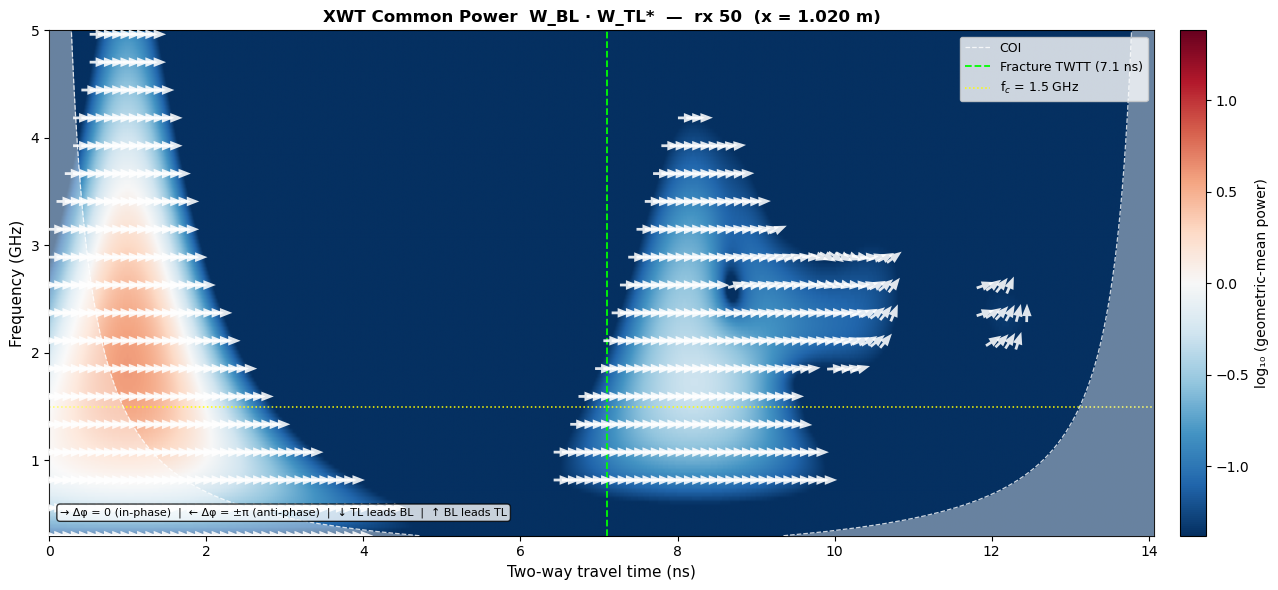

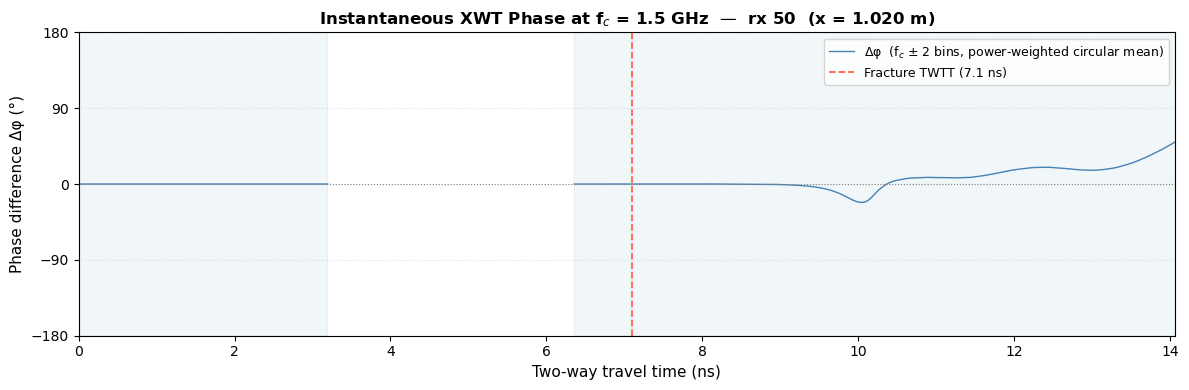


Batch XWT over all 100 receivers ...
   20 / 100
   40 / 100
   60 / 100
   80 / 100
  100 / 100
Done.


C:\Users\Administrator\AppData\Local\Temp\ipykernel_2544\119617105.py:240: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


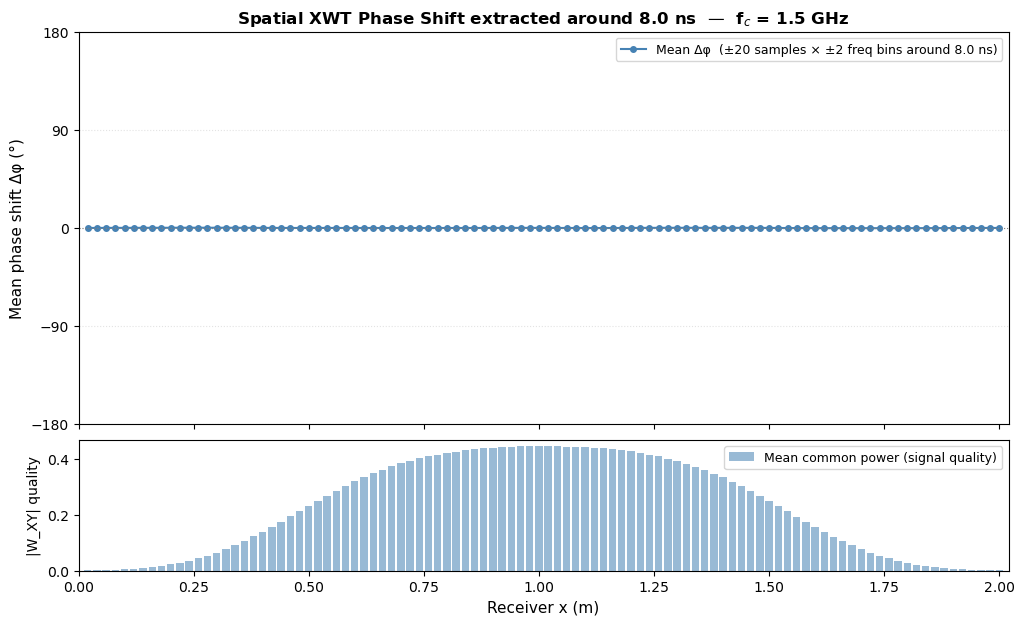

XWT analysis complete.


In [57]:
# ─────────────────────────────────────────────────────────────────────────────
# Cell 6 — Cross-Wavelet Transform (XWT): Baseline ↔ Timelapse phase analysis
#
#  Section 1 : XWT common-power spectrum + phase arrows (representative trace)
#  Section 2 : Frequency-locked instantaneous phase at f_central vs time
#  Section 3 : Spatial mean XWT phase at fracture depth vs receiver offset
# ─────────────────────────────────────────────────────────────────────────────
import numpy as np
import matplotlib.pyplot as plt
import pywt

# ══════════════════════════════════════════════════════════════════════════════
# Parameters
# ══════════════════════════════════════════════════════════════════════════════
XWT_TRACE    = len(rx_positions) // 2   # representative receiver index
N_FREQS      = 128                       # frequency bins
FREQ_MIN     = 0.3e9                     # [Hz]
FREQ_MAX     = 5.0e9                     # [Hz]
WAVELET      = "cmor1.5-1.0"
POWER_THRESH = 0.01     # suppress phase where common power < thresh × peak
ARROW_STRIDE_T = 60     # quiver sub-sampling stride for time axis
ARROW_STRIDE_F = 7     # quiver sub-sampling stride for frequency axis
ARROW_THRESH = 0.01     # separate threshold for arrow visibility
COI_ALPHA    = 0.40     # COI overlay opacity
F_WIN        = 2        # ±bins around f_central for phase extraction
T_WIN        = 20       # ±samples around target time for phase extraction (increased to catch wider wavelet)
T_TARGET     = 8.0      # [ns] Target extraction time for Section 3 (adjust this to hit the max reflection energy!)

# ── Derived quantities ───────────────────────────────────────────────────────
# Changed to linspace and origin='lower' to fix y-axis orientation and linear stretching
freqs_hz = np.linspace(FREQ_MIN, FREQ_MAX, N_FREQS)
scales   = pywt.frequency2scale(WAVELET, freqs_hz * dt_s)
t_frac   = fracture_depth / c_ice * 2 * 1e9          # fracture TWTT [ns]

# Note: We now use T_TARGET for the spatial extraction window so you can tune it past the theoretical TWTT
t_idx    = int(np.argmin(np.abs(time_ns - T_TARGET)))
f_idx    = int(np.argmin(np.abs(freqs_hz - f_central)))
f_lo, f_hi = max(0, f_idx - F_WIN),     min(N_FREQS,      f_idx + F_WIN + 1)
t_lo, t_hi = max(0, t_idx - T_WIN),     min(len(time_ns), t_idx + T_WIN + 1)

# extent: [t_min, t_max, f_min, f_max] for origin='lower'
extent   = [time_ns[0], time_ns[-1], freqs_hz[0] / 1e9, freqs_hz[-1] / 1e9]

print(f"Representative trace : rx {XWT_TRACE}  (x = {rx_positions[XWT_TRACE]:.3f} m)")
print(f"Fracture TWTT        : {t_frac:.2f} ns")
print(f"Section 3 Target Time: {T_TARGET:.2f} ns  → sample {t_idx}")
print(f"Center frequency     : {f_central/1e9:.2f} GHz  → freq bin {f_idx}  "
      f"({freqs_hz[f_idx]/1e9:.3f} GHz)")
print(f"Phase window         : t ±{T_WIN} samples, f ±{F_WIN} bins")


# ══════════════════════════════════════════════════════════════════════════════
# Helpers (self-contained — no dependency on Cell 5 functions)
# ══════════════════════════════════════════════════════════════════════════════

def _xwt(idx):
    """CWT pair + XWT for receiver idx.
    Returns (cwt_b, cwt_tl, W_XY, common_power, xwt_phase).
    common_power = sqrt(|W_b| * |W_tl|): non-zero only where both signals
    carry energy, used as the significance mask for phase display.
    """
    cb, _ = pywt.cwt(baseline_norm[idx],  scales, WAVELET, sampling_period=dt_s)
    ct, _ = pywt.cwt(timelapse_norm[idx], scales, WAVELET, sampling_period=dt_s)
    W     = cb * np.conj(ct)                    # W_XY = W_BL · W_TL*
    cp    = np.sqrt(np.abs(cb) * np.abs(ct))    # geometric-mean common power
    return cb, ct, W, cp, np.angle(W)


def _coi(ax, freqs_hz, time_ns, alpha=COI_ALPHA):
    """Semi-transparent white COI + dashed boundary on a (t, f) scalogram axes.
    COI half-width: t_coi(f) = sqrt(2) / f  [Torrence & Compo 1998].
    """
    T  = time_ns[-1]
    fg = freqs_hz / 1e9
    tc = np.sqrt(2) / freqs_hz * 1e9
    kw_f = dict(color="white", alpha=alpha, linewidth=0, zorder=3)
    ax.fill_betweenx(fg, time_ns[0], np.minimum(time_ns[0] + tc, T), **kw_f)
    ax.fill_betweenx(fg, np.maximum(T - tc, time_ns[0]), T,           **kw_f)
    valid = tc < 0.5 * (T - time_ns[0])
    if valid.any():
        kw_l = dict(color="white", ls="--", lw=0.9, alpha=0.80, zorder=4)
        ax.plot(time_ns[0] + tc[valid], fg[valid], **kw_l, label="COI")
        ax.plot(T           - tc[valid], fg[valid], **kw_l)


def _quiver(ax, ph, cp, time_ns, freqs_hz, stride_t, stride_f, thresh):
    """Phase arrows on a scalogram axes.
    Arrow direction (cos φ, sin φ):
      →  Δφ = 0      in-phase
      ←  Δφ = ±π     anti-phase
      ↓  Δφ < 0      TL phase leads BL (normal y-axis orientation)
      ↑  Δφ > 0      BL phase leads TL 
    """
    ts   = np.arange(0, ph.shape[1], stride_t)
    fs   = np.arange(0, ph.shape[0], stride_f)
    ph_s = ph[np.ix_(fs, ts)]
    cp_s = cp[np.ix_(fs, ts)]
    sig  = cp_s > thresh * cp.max()
    
    Tq, Fq = np.meshgrid(time_ns[ts], freqs_hz[fs] / 1e9)
    Tq_sig = Tq[sig]
    Fq_sig = Fq[sig]
    U_sig  = np.cos(ph_s[sig])
    V_sig  = np.sin(ph_s[sig])
    
    ax.quiver(Tq_sig, Fq_sig, U_sig, V_sig,
              scale=60, headwidth=3.5, headlength=4.5,
              color="white", alpha=0.88, width=0.0025, zorder=5, pivot='mid')


def _phase_locked(ph, cp, f_lo, f_hi, thresh):
    """Power-weighted circular mean of XWT phase over freq bins [f_lo:f_hi].
    Uses complex averaging to handle ±π wrapping correctly.
    Returns per-time 1-D array; NaN where total weight < thresh × global peak.
    """
    w  = cp[f_lo:f_hi, :]
    z  = np.sum(w * np.exp(1j * ph[f_lo:f_hi, :]), axis=0)
    sw = w.sum(axis=0) + 1e-30
    return np.where(sw - 1e-30 > thresh * cp.max(), np.angle(z / sw), np.nan)


# ══════════════════════════════════════════════════════════════════════════════
# Section 1 — XWT common-power spectrum + phase arrows
# ══════════════════════════════════════════════════════════════════════════════
cb, ct, xwt, common_pw, xwt_ph = _xwt(XWT_TRACE)

# log10 common power: high = red, low = blue (diverging around 0 = unit power)
log_cp = np.log10(common_pw + 1e-14)
sig_px = log_cp[common_pw > POWER_THRESH * common_pw.max()]
vlim   = np.percentile(np.abs(sig_px), 97) if sig_px.size else 1.0

fig1, ax1 = plt.subplots(figsize=(14, 6))
im1 = ax1.imshow(log_cp, aspect="auto", cmap="RdBu_r", origin="lower",
                 extent=extent, vmin=-vlim, vmax=vlim)

# Use ARROW_THRESH to restrict phase arrows to high-power regions
_quiver(ax1, xwt_ph, common_pw, time_ns, freqs_hz, ARROW_STRIDE_T, ARROW_STRIDE_F, ARROW_THRESH)
_coi(ax1, freqs_hz, time_ns)

ax1.axvline(t_frac,          color="lime",   ls="--", lw=1.3,
            label=f"Fracture TWTT ({t_frac:.1f} ns)")
ax1.axhline(f_central / 1e9, color="yellow", ls=":",  lw=1.1,
            label=f"f$_c$ = {f_central/1e9:.1f} GHz")
ax1.legend(fontsize=9, loc="upper right")
ax1.set_title(
    f"XWT Common Power  W_BL · W_TL*  —  "
    f"rx {XWT_TRACE}  (x = {rx_positions[XWT_TRACE]:.3f} m)",
    fontsize=12, weight="bold")
ax1.set_xlabel("Two-way travel time (ns)", fontsize=11)
ax1.set_ylabel("Frequency (GHz)", fontsize=11)
cbar1 = fig1.colorbar(im1, ax=ax1, pad=0.02)
cbar1.set_label("log₁₀ (geometric-mean power)", fontsize=10)
ax1.text(0.01, 0.04,
         "→ Δφ = 0 (in-phase)  |  ← Δφ = ±π (anti-phase)  "
         "|  ↓ TL leads BL  |  ↑ BL leads TL",
         transform=ax1.transAxes, fontsize=8,
         bbox=dict(fc="white", alpha=0.78, boxstyle="round,pad=0.3"), zorder=6)
plt.tight_layout()
plt.show()


# ══════════════════════════════════════════════════════════════════════════════
# Section 2 — Frequency-locked instantaneous XWT phase at f_central vs time
# ══════════════════════════════════════════════════════════════════════════════
ph_locked = _phase_locked(xwt_ph, common_pw, f_lo, f_hi, POWER_THRESH)

fig2, ax2 = plt.subplots(figsize=(12, 4))
ax2.plot(time_ns, np.degrees(ph_locked), color="steelblue", lw=1.0,
         label=f"Δφ  (f$_c$ ± {F_WIN} bins, power-weighted circular mean)")
ax2.fill_between(time_ns,
                 np.where(~np.isnan(ph_locked), -180, np.nan),
                 np.where(~np.isnan(ph_locked),  180, np.nan),
                 alpha=0.07, color="steelblue")         # signal-coverage shading
ax2.axvline(t_frac, color="tomato", ls="--", lw=1.3,
            label=f"Fracture TWTT ({t_frac:.1f} ns)")
ax2.axhline(0, color="gray", ls=":", lw=0.8)
ax2.set_xlim(time_ns[0], time_ns[-1])
ax2.set_ylim(-180, 180)
ax2.set_yticks([-180, -90, 0, 90, 180])
ax2.set_title(
    f"Instantaneous XWT Phase at f$_c$ = {f_central/1e9:.1f} GHz  —  "
    f"rx {XWT_TRACE}  (x = {rx_positions[XWT_TRACE]:.3f} m)",
    fontsize=12, weight="bold")
ax2.set_xlabel("Two-way travel time (ns)", fontsize=11)
ax2.set_ylabel("Phase difference Δφ (°)", fontsize=11)
ax2.legend(fontsize=9)
ax2.grid(axis="y", ls=":", alpha=0.35)
plt.tight_layout()
plt.show()


# ══════════════════════════════════════════════════════════════════════════════
# Section 3 — Spatial: mean XWT phase at fracture depth vs receiver offset
# ══════════════════════════════════════════════════════════════════════════════
print(f"\nBatch XWT over all {len(rx_positions)} receivers ...")
mean_phase_deg = np.full(len(rx_positions), np.nan)
mean_cp_val    = np.full(len(rx_positions), np.nan)

for i in range(len(rx_positions)):
    _, _, _, cp_i, ph_i = _xwt(i)
    # Power-weighted circular mean over the (f_central ± F_WIN) × (T_TARGET ± T_WIN) window
    w_win  = cp_i[f_lo:f_hi, t_lo:t_hi]
    ph_win = ph_i[f_lo:f_hi, t_lo:t_hi]
    total  = w_win.sum()
    if total > 0:
        mean_phase_deg[i] = np.degrees(
            np.angle(np.sum(w_win * np.exp(1j * ph_win)) / total)
        )
        mean_cp_val[i] = total / w_win.size
    if (i + 1) % 20 == 0 or i == len(rx_positions) - 1:
        print(f"  {i+1:3d} / {len(rx_positions)}")

print("Done.")

fig3, (ax3a, ax3b) = plt.subplots(
    2, 1, figsize=(12, 7), sharex=True,
    gridspec_kw={"height_ratios": [3, 1], "hspace": 0.06})

ax3a.plot(rx_positions, mean_phase_deg,
          color="steelblue", lw=1.5, marker="o", ms=4,
          label=f"Mean Δφ  (±{T_WIN} samples × ±{F_WIN} freq bins around {T_TARGET:.1f} ns)")
ax3a.axhline(0, color="gray", ls=":", lw=0.8)
ax3a.set_ylim(-180, 180)
ax3a.set_yticks([-180, -90, 0, 90, 180])
ax3a.set_ylabel("Mean phase shift Δφ (°)", fontsize=11)
ax3a.set_title(
    f"Spatial XWT Phase Shift extracted around {T_TARGET:.1f} ns  —  "
    f"f$_c$ = {f_central/1e9:.1f} GHz",
    fontsize=12, weight="bold")
ax3a.legend(fontsize=9)
ax3a.grid(axis="y", ls=":", alpha=0.35)

ax3b.bar(rx_positions, mean_cp_val, width=rx_spacing * 0.8,
         color="steelblue", alpha=0.55, label="Mean common power (signal quality)")
ax3b.set_ylabel("|W_XY| quality", fontsize=10)
ax3b.set_xlabel("Receiver x (m)", fontsize=11)
ax3b.set_xlim(rx_positions[0] - rx_spacing, rx_positions[-1] + rx_spacing)
ax3b.legend(fontsize=9)

plt.tight_layout()
plt.show()
print("XWT analysis complete.")

Late-Time Representative trace : rx 50  (x = 1.020 m)
Fracture TWTT        : 7.10 ns  → sub-sample 626 (relative to T_START=6.0ns)
Center frequency     : 1.50 GHz


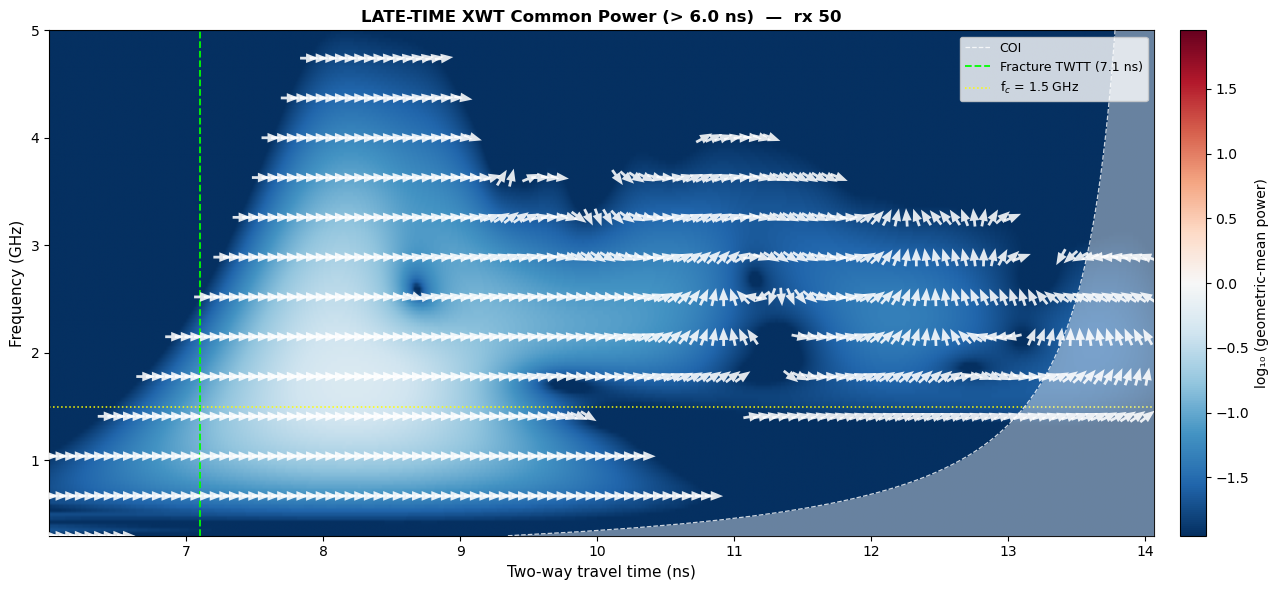

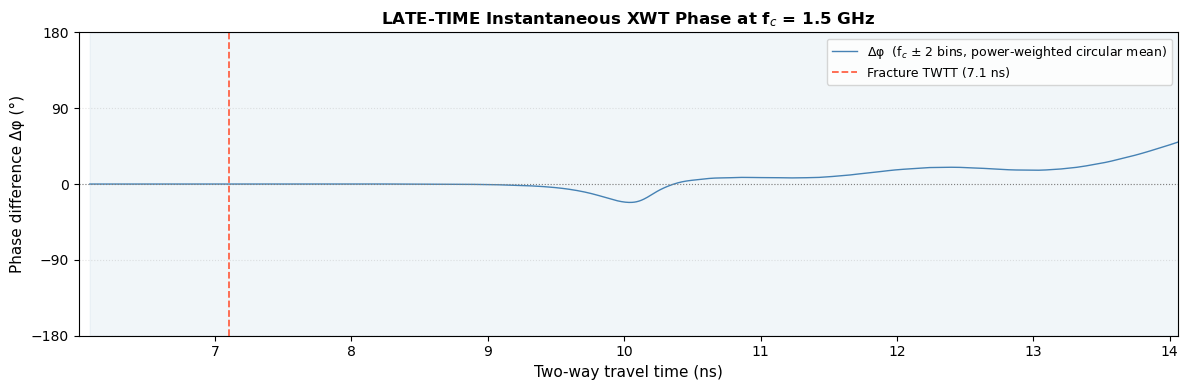

In [49]:
# ─────────────────────────────────────────────────────────────────────────────
# Cell 7 — Cross-Wavelet Transform (XWT): Late-time Analysis (> 6 ns)
#
# Doing CWT on full trace, but subsetting the post-6ns data before scaling
# and plotting, to avoid earlier ground waves dominating the power normalization.
# ─────────────────────────────────────────────────────────────────────────────
import numpy as np
import matplotlib.pyplot as plt
import pywt

# ══════════════════════════════════════════════════════════════════════════════
# Parameters
# ══════════════════════════════════════════════════════════════════════════════
XWT_TRACE    = len(rx_positions) // 2   # representative receiver index
N_FREQS      = 128                       
FREQ_MIN     = 0.3e9                     
FREQ_MAX     = 5.0e9                     
WAVELET      = "cmor1.5-1.0"
POWER_THRESH = 0.02     
ARROW_STRIDE_T = 40      # quiver sub-sampling stride for time axis
ARROW_STRIDE_F = 10      # quiver sub-sampling stride for frequency axis
ARROW_THRESH = 0.02     
COI_ALPHA    = 0.40     
F_WIN        = 2        
T_WIN        = 5        
T_START      = 6.0      # [ns] Focus only on late-time arrivals

# ── Derived quantities ───────────────────────────────────────────────────────
freqs_hz = np.linspace(FREQ_MIN, FREQ_MAX, N_FREQS)
scales   = pywt.frequency2scale(WAVELET, freqs_hz * dt_s)
t_frac   = fracture_depth / c_ice * 2 * 1e9          # fracture TWTT [ns]

# Time bounds mapping
t_mask = time_ns >= T_START
time_sub = time_ns[t_mask]
t_start_idx = np.argmax(t_mask)

# Re-map t_idx relative to the cropped subset array
t_idx    = int(np.argmin(np.abs(time_sub - t_frac)))
f_idx    = int(np.argmin(np.abs(freqs_hz - f_central)))
f_lo, f_hi = max(0, f_idx - F_WIN),     min(N_FREQS,      f_idx + F_WIN + 1)
t_lo, t_hi = max(0, t_idx - T_WIN),     min(len(time_sub), t_idx + T_WIN + 1)

extent_sub = [time_sub[0], time_sub[-1], freqs_hz[0] / 1e9, freqs_hz[-1] / 1e9]

print(f"Late-Time Representative trace : rx {XWT_TRACE}  (x = {rx_positions[XWT_TRACE]:.3f} m)")
print(f"Fracture TWTT        : {t_frac:.2f} ns  → sub-sample {t_idx} (relative to T_START={T_START}ns)")
print(f"Center frequency     : {f_central/1e9:.2f} GHz")

# ══════════════════════════════════════════════════════════════════════════════
# Helpers
# ══════════════════════════════════════════════════════════════════════════════
def _xwt_late(idx):
    cb, _ = pywt.cwt(baseline_norm[idx],  scales, WAVELET, sampling_period=dt_s)
    ct, _ = pywt.cwt(timelapse_norm[idx], scales, WAVELET, sampling_period=dt_s)
    # Subselect the time series after the CWT transforms it, preventing 
    # missing energy or edge padding artifacts at 6 ns
    cb = cb[:, t_start_idx:]
    ct = ct[:, t_start_idx:]
    W     = cb * np.conj(ct)
    cp    = np.sqrt(np.abs(cb) * np.abs(ct))
    return cb, ct, W, cp, np.angle(W)

def _coi_late(ax, freqs_hz, time_ns, time_sub, alpha=COI_ALPHA):
    T  = time_ns[-1]
    fg = freqs_hz / 1e9
    tc = np.sqrt(2) / freqs_hz * 1e9
    kw_f = dict(color="white", alpha=alpha, linewidth=0, zorder=3)
    coi_left = np.maximum(time_ns[0] + tc, time_sub[0])
    ax.fill_betweenx(fg, time_sub[0], np.minimum(coi_left, T), **kw_f)
    coi_right = np.maximum(T - tc, time_sub[0])
    ax.fill_betweenx(fg, coi_right, T, **kw_f)
    valid = tc < 0.5 * (T - time_ns[0])
    if valid.any():
        kw_l = dict(color="white", ls="--", lw=0.9, alpha=0.80, zorder=4)
        ax.plot(time_ns[0] + tc[valid], fg[valid], **kw_l, label="COI")
        ax.plot(T - tc[valid], fg[valid], **kw_l)

def _quiver_late(ax, ph, cp, time_sub, freqs_hz, stride_t, stride_f, thresh):
    ts   = np.arange(0, ph.shape[1], stride_t)
    fs   = np.arange(0, ph.shape[0], stride_f)
    ph_s = ph[np.ix_(fs, ts)]
    cp_s = cp[np.ix_(fs, ts)]
    sig  = cp_s > thresh * cp.max()
    Tq, Fq = np.meshgrid(time_sub[ts], freqs_hz[fs] / 1e9)
    Tq_sig = Tq[sig]
    Fq_sig = Fq[sig]
    U_sig  = np.cos(ph_s[sig])
    V_sig  = np.sin(ph_s[sig])
    
    # Scale adjusts the length (higher is smaller arrows). Width is relative line thickness.
    ax.quiver(Tq_sig, Fq_sig, U_sig, V_sig,
              scale=60, headwidth=3.5, headlength=4.5,
              color="white", alpha=0.88, width=0.0025, zorder=5, pivot='mid')

def _phase_locked(ph, cp, f_lo, f_hi, thresh):
    w  = cp[f_lo:f_hi, :]
    z  = np.sum(w * np.exp(1j * ph[f_lo:f_hi, :]), axis=0)
    sw = w.sum(axis=0) + 1e-30
    return np.where(sw - 1e-30 > thresh * cp.max(), np.angle(z / sw), np.nan)

# ══════════════════════════════════════════════════════════════════════════════
# Section 1
# ══════════════════════════════════════════════════════════════════════════════
cb, ct, xwt, common_pw, xwt_ph = _xwt_late(XWT_TRACE)

log_cp = np.log10(common_pw + 1e-14)
sig_px = log_cp[common_pw > POWER_THRESH * common_pw.max()]
vlim   = np.percentile(np.abs(sig_px), 97) if sig_px.size else 1.0

fig1, ax1 = plt.subplots(figsize=(14, 6))
im1 = ax1.imshow(log_cp, aspect="auto", cmap="RdBu_r", origin="lower",
                 extent=extent_sub, vmin=-vlim, vmax=vlim)

_quiver_late(ax1, xwt_ph, common_pw, time_sub, freqs_hz, ARROW_STRIDE_T, ARROW_STRIDE_F, ARROW_THRESH)
_coi_late(ax1, freqs_hz, time_ns, time_sub)

ax1.axvline(t_frac,          color="lime",   ls="--", lw=1.3,
            label=f"Fracture TWTT ({t_frac:.1f} ns)")
ax1.axhline(f_central / 1e9, color="yellow", ls=":",  lw=1.1,
            label=f"f$_c$ = {f_central/1e9:.1f} GHz")

ax1.legend(fontsize=9, loc="upper right")
ax1.set_xlim(time_sub[0], time_sub[-1])
ax1.set_title(f"LATE-TIME XWT Common Power (> {T_START} ns)  —  rx {XWT_TRACE}", fontsize=12, weight="bold")
ax1.set_xlabel("Two-way travel time (ns)", fontsize=11)
ax1.set_ylabel("Frequency (GHz)", fontsize=11)
cbar1 = fig1.colorbar(im1, ax=ax1, pad=0.02)
cbar1.set_label("log₁₀ (geometric-mean power)", fontsize=10)
plt.tight_layout()
plt.show()

# ══════════════════════════════════════════════════════════════════════════════
# Section 2 
# ══════════════════════════════════════════════════════════════════════════════
ph_locked = _phase_locked(xwt_ph, common_pw, f_lo, f_hi, POWER_THRESH)

fig2, ax2 = plt.subplots(figsize=(12, 4))
ax2.plot(time_sub, np.degrees(ph_locked), color="steelblue", lw=1.0,
         label=f"Δφ  (f$_c$ ± {F_WIN} bins, power-weighted circular mean)")
ax2.fill_between(time_sub,
                 np.where(~np.isnan(ph_locked), -180, np.nan),
                 np.where(~np.isnan(ph_locked),  180, np.nan),
                 alpha=0.07, color="steelblue")         
ax2.axvline(t_frac, color="tomato", ls="--", lw=1.3,
            label=f"Fracture TWTT ({t_frac:.1f} ns)")
ax2.axhline(0, color="gray", ls=":", lw=0.8)
ax2.set_xlim(time_sub[0], time_sub[-1])
ax2.set_ylim(-180, 180)
ax2.set_yticks([-180, -90, 0, 90, 180])
ax2.set_title(f"LATE-TIME Instantaneous XWT Phase at f$_c$ = {f_central/1e9:.1f} GHz", fontsize=12, weight="bold")
ax2.set_xlabel("Two-way travel time (ns)", fontsize=11)
ax2.set_ylabel("Phase difference Δφ (°)", fontsize=11)
ax2.legend(fontsize=9)
ax2.grid(axis="y", ls=":", alpha=0.35)
plt.tight_layout()
plt.show()

# # ══════════════════════════════════════════════════════════════════════════════
# # Section 3
# # ══════════════════════════════════════════════════════════════════════════════
# print(f"\nBatch XWT over all {len(rx_positions)} receivers ...")
# mean_phase_deg = np.full(len(rx_positions), np.nan)
# mean_cp_val    = np.full(len(rx_positions), np.nan)

# for i in range(len(rx_positions)):
#     _, _, _, cp_i, ph_i = _xwt_late(i)
#     w_win  = cp_i[f_lo:f_hi, t_lo:t_hi]
#     ph_win = ph_i[f_lo:f_hi, t_lo:t_hi]
#     total  = w_win.sum()
#     if total > 0:
#         mean_phase_deg[i] = np.degrees(
#             np.angle(np.sum(w_win * np.exp(1j * ph_win)) / total)
#         )
#         mean_cp_val[i] = total / w_win.size

# fig3, (ax3a, ax3b) = plt.subplots(
#     2, 1, figsize=(12, 7), sharex=True,
#     gridspec_kw={"height_ratios": [3, 1], "hspace": 0.06})

# ax3a.plot(rx_positions, mean_phase_deg, color="steelblue", lw=1.5, marker="o", ms=4,
#           label=f"Mean Δφ (±{T_WIN} samples × ±{F_WIN} freq bins)")
# ax3a.axhline(0, color="gray", ls=":", lw=0.8)
# ax3a.set_ylim(-180, 180)
# ax3a.set_yticks([-180, -90, 0, 90, 180])
# ax3a.set_ylabel("Mean phase shift Δφ (°)", fontsize=11)
# ax3a.set_title(f"LATE-TIME Spatial XWT Phase Shift at Fracture Depth ({fracture_depth} m)", fontsize=12, weight="bold")
# ax3a.legend(fontsize=9)
# ax3a.grid(axis="y", ls=":", alpha=0.35)

# ax3b.bar(rx_positions, mean_cp_val, width=rx_spacing * 0.8,
#          color="steelblue", alpha=0.55, label="Mean common power")
# ax3b.set_ylabel("|W_XY| quality", fontsize=10)
# ax3b.set_xlabel("Receiver x (m)", fontsize=11)
# ax3b.set_xlim(rx_positions[0] - rx_spacing, rx_positions[-1] + rx_spacing)
# ax3b.legend(fontsize=9)
# plt.tight_layout()
# plt.show()
# print("Late-time XWT analysis complete.")